# Statistics Deep Dive — Start Here

**A hands-on statistics course in 13 Jupyter notebooks** — from describing a single variable to regression, Bayesian inference and forecasting. Every concept is explained in prose, derived with the necessary formulas, **made visible with simulations and plots**, and then applied in a **real-world use-case exercise** with a fully worked solution.

### Who is this for?
Analysts, engineers, scientists and students who want to *understand* statistics rather than memorise recipes. You should be comfortable reading basic Python (NumPy / pandas); no prior statistics is assumed, but the pace is brisk and the later modules go deep.

### How each module is built
1. **Concept** — the idea in plain language, then the formula, then the pitfalls.
2. **🤔 Predict first** — short prompts that ask you to commit to an answer *before* you run the next cell. Do it: predicting and being surprised is how intuition forms.
3. **Visual demonstration** — nearly every idea is simulated and plotted. Change the numbers and re-run; the notebooks are meant to be played with.
4. **✍️ Exercises — real-world use cases** — one for every core method, each a small business, engineering, medical or policy problem with its own data set. Work in the empty cell below the task.
5. **Solutions** — in `solutions/NN_..._solutions.ipynb`: executed code, plots and an *interpretation* — because in real projects the numbers are only half of the answer.
6. **🔑 Key takeaways and a cheat sheet** of the most useful function calls.

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

---
## 1. Check your environment

The course needs Python ≥ 3.9 and the standard scientific stack. Install everything with `pip install -r requirements.txt`, then run the next cell. All data sets are either simulated inside the notebooks or bundled with scikit-learn / statsmodels — **no internet connection is needed**.

In [2]:
import importlib, sys
print(f"Python {sys.version.split()[0]}")
for pkg, minimum in [("numpy", "1.24"), ("pandas", "2.0"), ("scipy", "1.11"), ("matplotlib", "3.7"), ("seaborn", "0.12"), ("statsmodels", "0.14"), ("sklearn", "1.3")]:
    try:
        print(f"  {pkg:12s} {importlib.import_module(pkg).__version__:10s} (needs ≥ {minimum})")
    except ImportError:
        print(f"  {pkg:12s} MISSING  ->  pip install {'scikit-learn' if pkg == 'sklearn' else pkg}")
try:
    import ipywidgets; print(f"  ipywidgets   {ipywidgets.__version__:10s} (optional: sliders in the interactive explorers of Modules 3 and 4)")
except ImportError:
    print("  ipywidgets   not installed (optional) — the interactive explorers fall back to static plots")

Python 3.12.3
  numpy        2.4.4      (needs ≥ 1.24)
  pandas       3.0.2      (needs ≥ 2.0)
  scipy        1.17.1     (needs ≥ 1.11)
  matplotlib   3.10.8     (needs ≥ 3.7)
  seaborn      0.13.2     (needs ≥ 0.12)
  statsmodels  0.15.0     (needs ≥ 0.14)
  sklearn      1.8.0      (needs ≥ 1.3)
  ipywidgets   not installed (optional) — the interactive explorers fall back to static plots


---
## 2. The course map

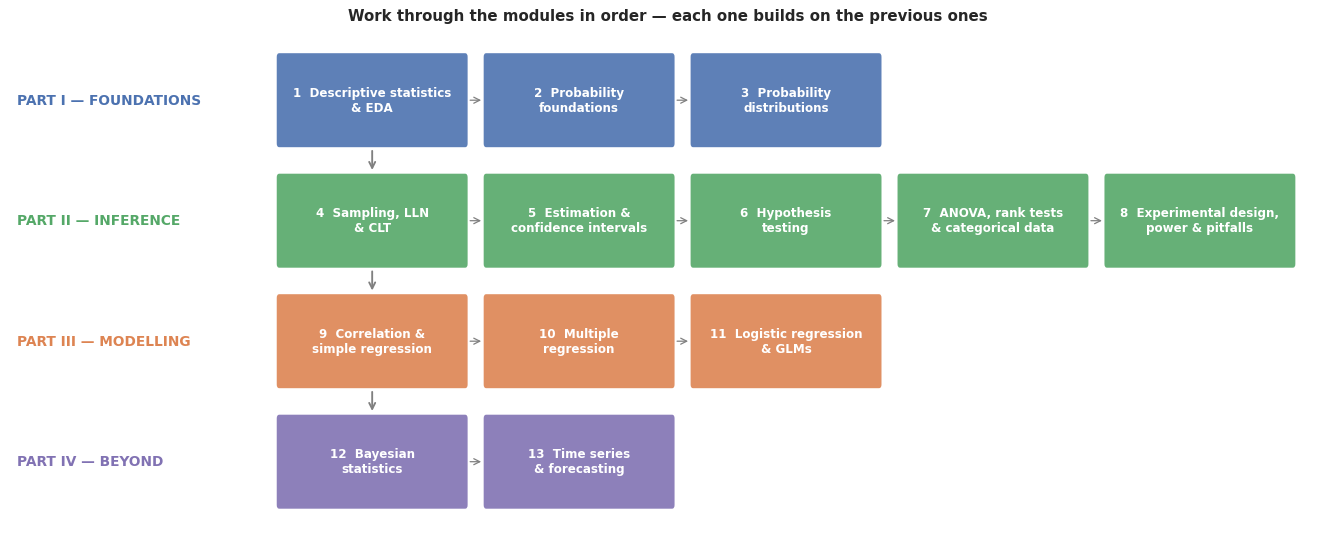

In [3]:
from matplotlib.patches import FancyBboxPatch
parts = [("PART I — FOUNDATIONS", C[0], ["1  Descriptive statistics\n& EDA", "2  Probability\nfoundations", "3  Probability\ndistributions"]),
         ("PART II — INFERENCE", C[2], ["4  Sampling, LLN\n& CLT", "5  Estimation &\nconfidence intervals", "6  Hypothesis\ntesting", "7  ANOVA, rank tests\n& categorical data", "8  Experimental design,\npower & pitfalls"]),
         ("PART III — MODELLING", C[1], ["9  Correlation &\nsimple regression", "10  Multiple\nregression", "11  Logistic regression\n& GLMs"]),
         ("PART IV — BEYOND", C[4], ["12  Bayesian\nstatistics", "13  Time series\n& forecasting"])]
fig, ax = plt.subplots(figsize=(15, 6.2)); ax.axis("off")
for row, (title, col, modules) in enumerate(parts):
    y = 3 - row; ax.text(0, y, title, va="center", fontsize=11, fontweight="bold", color=col)
    for k, name in enumerate(modules):
        x = 3.1 + k * 2.45
        ax.add_patch(FancyBboxPatch((x, y - .36), 2.2, .72, boxstyle="round,pad=0.03", fc=col, ec="none", alpha=.9))
        ax.text(x + 1.1, y, name, ha="center", va="center", color="white", fontsize=9.5, fontweight="bold")
        if k: ax.annotate("", xy=(x - .03, y), xytext=(x - .22, y), arrowprops=dict(arrowstyle="->", color="grey"))
    if row < 3: ax.annotate("", xy=(3.1 + 1.1, y - 1 + .4), xytext=(3.1 + 1.1, y - .4), arrowprops=dict(arrowstyle="->", color="grey", lw=1.5))
ax.set(xlim=(-.1, 15.5), ylim=(-.6, 3.6)); ax.set_title("Work through the modules in order — each one builds on the previous ones", fontsize=12)
plt.tight_layout(); plt.show()

| # | Module | Core concepts | Real-world exercises |
|---|---|---|---|
| 1 | **Descriptive statistics & EDA** | scales, centre, spread, quantiles, shape, outliers, Anscombe | salary statistics for a job ad · courier service levels · cold-chain sensor log · wine profiling *(real data)* |
| 2 | **Probability foundations** | rules, conditional probability, Bayes, expectation, Monte Carlo | spam filter · server-rack reliability · fraud false alarms · warranty pricing · project-deadline risk |
| 3 | **Probability distributions** | binomial, Poisson, normal, exponential, log-normal, $t$/$\chi^2$/$F$, Q–Q plots, fitting | acceptance sampling · call-centre staffing · Six-Sigma tolerances · pump failures · insurance tail risk |
| 4 | **Sampling, LLN & CLT** | sampling designs, bias, sampling distributions, standard error, CLT | poll sample size · inventory audit · bottling-line control · latency alerts · biased survey |
| 5 | **Estimation & confidence intervals** | bias/variance/MSE, maximum likelihood, CIs, Wilson, bootstrap | German tank problem · subscriber lifetimes (censoring) · basket value · zero-defect claims · A/B revenue lift |
| 6 | **Hypothesis testing** | p-values, errors & power, $t$-tests, proportions, permutation tests, effect sizes | filling machine · blood-pressure trial · fuel additive (paired) · checkout A/B test · physiotherapy pilot |
| 7 | **ANOVA, rank tests & categorical data** | one-/two-way ANOVA, Tukey, Mann–Whitney, Kruskal–Wallis, $\chi^2$, Fisher, RR/OR | fertiliser trial · channel × discount · app ratings · Benford fraud screen · plan vs. age · migraine trial |
| 8 | **Experimental design, power & pitfalls** | randomisation, Simpson, power, winner's curse, multiple testing, peeking, CUPED, regression to the mean | Berkeley admissions *(real data)* · A/B test duration · 25 segments · optional stopping · CUPED · speed cameras |
| 9 | **Correlation & simple regression** | Pearson/Spearman, confounding, OLS, $R^2$, confidence vs. prediction bands, diagnostics, transformations | ad spend · firefighters & damage · price per m² · gas demand · stopping distance |
| 10 | **Multiple regression** | partial effects, omitted-variable bias, dummies, interactions, VIF, influence, robust SEs, CV, ridge/lasso | house prices · pay-gap audit · marketing mix · insurance charges · diabetes progression *(real data)* |
| 11 | **Logistic regression & GLMs** | odds & logit, MLE, odds ratios, ROC/AUC, calibration, cost-based thresholds, Poisson regression, offsets | telecom churn · credit scoring · breast-cancer diagnosis *(real data)* · motor-insurance claim frequency |
| 12 | **Bayesian statistics** | prior/posterior, conjugacy, credible intervals, Bayesian A/B tests, posterior prediction, shrinkage, MCMC | product launch · e-mail subject lines · on-call sizing · marketplace ranking · Challenger O-rings *(real data)* |
| 13 | **Time series & forecasting** | components, ACF/PACF, smoothing, STL, stationarity, spurious regression, SARIMA, rolling-origin evaluation | daily orders · tourism seasonality · share prices · electricity demand · retail sales |

---
## 3. How to get the most out of it

* **Budget 3–5 hours per module**: about half for the lesson, half for the exercises. One module per week is a sustainable pace.
* **Run every cell, then break things.** Change a sample size, a seed, an effect size; watch what happens to the plot. Most "aha" moments in statistics come from seeing a simulation contradict your expectation.
* **Attempt every exercise before opening the solution** — even a wrong attempt makes the solution stick. Compare not only the numbers but also the *interpretation*.
* **Keep a "traps" list.** Each module highlights classic mistakes (⚠️). Collect them; they are what distinguishes a careful analyst.
* Every notebook is **self-contained and reproducible**: it starts with the same setup cell, uses seeded random generators, and every exercise creates its own data.

> 🛠️ **One convention to know:** in all notebooks `C` is the colour palette (`C[0]` blue, `C[1]` orange, …) and `rng` a seeded NumPy random generator. Because the name `C` is taken, model formulas never use patsy's `C(...)` wrapper; categorical columns are stored as text or as pandas categoricals instead.

**Ready? Open `01_descriptive_statistics.ipynb`.**